In [19]:
from matplotlib.lines import Line2D

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
from transects import transects, plot_transects

os.chdir('C:/Users/Budniak Piotr/met_liniowa/wyniki_wariantow_transektow')

def oblicz(x, odl, n_trans):
    miaższosc = x.MIAZSZOSC.sum() / 400 * 10000
    len_trans = (x.PROMIEN_A.iloc[0] * n_trans - n_trans * odl) / 100
    suma_kw_srednic = ((x.D12 / 10)**2 * x.przeciecia).sum()
    miazszosc_liniowa = 1.2337 / len_trans * suma_kw_srednic

    return pd.Series({'zasobnosc': miaższosc, 'zasob_lin': miazszosc_liniowa})

result_df = pd.DataFrame()

for i in os.listdir():
    if i.endswith('.parquet'):
        try:
            odl = int(i.split('_')[-1][4:7])
        except ValueError:
            odl = 0
            
        n_trans = int(i.split('_')[1][-1])

        df = pd.read_parquet(i)
        #Dla uproszczenia wybieramy tylko powierzchnie niepodzielone
        df = df[df.NR_PODPOW.astype(str).str[-2] == '0']

        wynik_df = df.groupby('NR_PODPOW', as_index=False).apply(oblicz, odl=odl, n_trans=n_trans)

        trans_len = n_trans * 1128 - n_trans * odl

        zasob_mean =wynik_df.zasobnosc.mean()
        zasob_lin_mean = wynik_df.zasob_lin.mean()

        roznica = wynik_df['zasob_lin'] - wynik_df['zasobnosc']
        bias = roznica.mean()
        mae = roznica.abs().mean()
        rmse = np.sqrt((roznica**2).mean())
        srednia_referencyjna = wynik_df['zasobnosc'].mean()
        rmse_procent = (rmse / srednia_referencyjna) * 100
        spearman_corr, spearman_p = stats.spearmanr(wynik_df['zasobnosc'], wynik_df['zasob_lin'])

        res = pd.Series({'trans_len': trans_len, 
                   'zasob_mean': zasob_mean, 
                   'zasob_lin_mean': zasob_lin_mean, 
                   'bias': bias, 'mae': mae, 
                   'rmse': rmse, 
                   'rmse_procent': rmse_procent, 
                   'spearman_corr': spearman_corr, 
                   'spearman_p': spearman_p},
                   name = i[:-8]).to_frame()
        
        result_df = pd.concat([result_df, res], axis=1)

result_df_T = result_df.T
result_df_T['trans_len'] = result_df_T['trans_len'] / 100
result_df_T['n_trans'] = list((result_df_T.index.get_level_values(0).str[8].astype(int) ** 2) * 10)

# Wyznacz front Pareto (min rmse_procent, min trans_len)
def pareto_mask(df, c1, c2):
    pts = df[[c1, c2]].values
    is_pareto = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        for j in range(len(pts)):
            if i != j:
                if pts[j,0] <= pts[i,0] and pts[j,1] <= pts[i,1] and (pts[j,0] < pts[i,0] or pts[j,1] < pts[i,1]):
                    is_pareto[i] = False
                    break
    return is_pareto

pareto_mask = pareto_mask(result_df_T, 'rmse_procent', 'trans_len')
pareto_front = result_df_T[pareto_mask]
pareto_front = pareto_front.sort_values('trans_len')
recommended = pareto_front[pareto_front.index == 'n_trans-3_angle-30_odl-0']


In [9]:
lokiec = pareto_front.iloc[[0,6,-1],:]

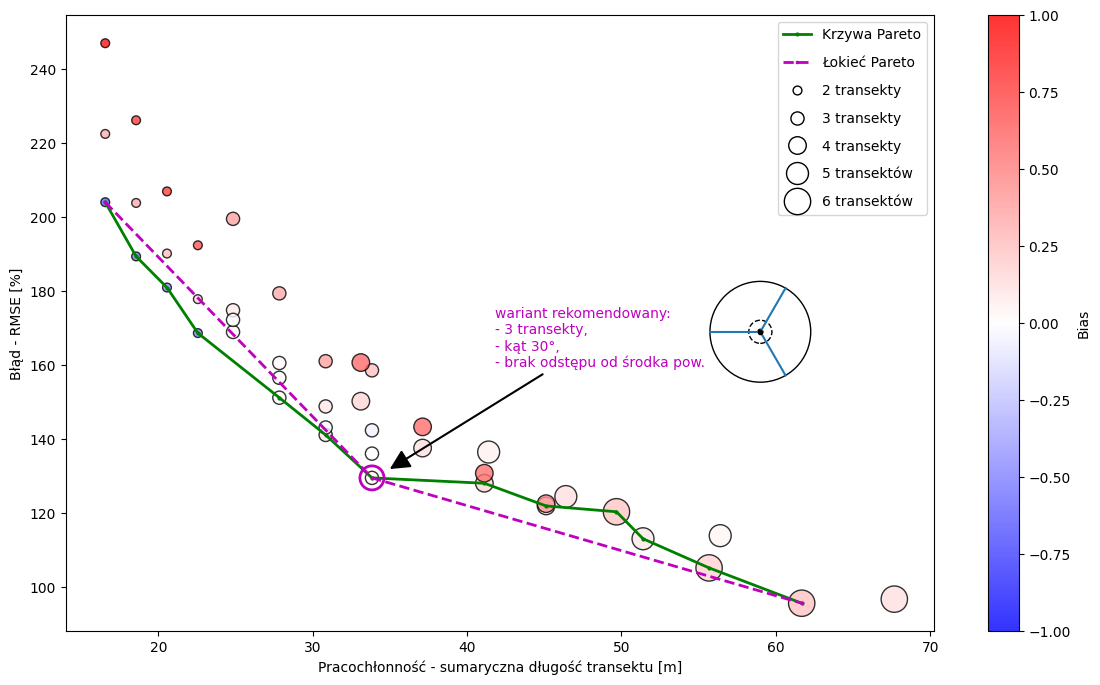

In [27]:
fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(x = 'trans_len',
            y = 'rmse_procent', 
            data = result_df_T,
            s = 'n_trans',
            c = 'bias',
            cmap="bwr",
            vmin = -1,
            vmax = 1,
            edgecolor = 'black',
            alpha = .8)

ax.scatter(recommended['trans_len'], recommended['rmse_procent'],
           s=300, 
           facecolors='none', 
           edgecolors='m', 
           linewidths=2, 
           zorder=4)

ax.annotate('wariant rekomendowany:\n- 3 transekty,\n- kąt 30°,\n- brak odstępu od środka pow.',
            xy=(recommended['trans_len'].values[0]+1, recommended['rmse_procent'].values[0]+2),
            xytext=(recommended['trans_len'].values[0] + 8, recommended['rmse_procent'].values[0] + 30),
            arrowprops=dict(arrowstyle='-|>, head_width=0.6, head_length=1.2', color='black', lw=1.5, zorder=5),
            fontsize=10, color='m', zorder=5)

ax.plot(pareto_front['trans_len'], 
        pareto_front['rmse_procent'],  
        color='green', 
        linestyle='-', 
        linewidth=2,
        marker='o',
        markersize=2,
        label='Krzywa Pareto')

ax.plot(lokiec['trans_len'],
        lokiec['rmse_procent'],
        color='m',
        linestyle='--',
        linewidth=2,
        marker='s',
        markersize=2,
        label='Łokieć Pareto')

axin = ax.inset_axes(
        [54, 154, 10, 30], transform = ax.transData)
axin.set_axis_off()
axin.set_aspect('equal')
res = (transects(num = 3, angle = 30, dist_start=0))
plot_transects(res, ax=axin)

ax.set_xlabel('Pracochłonność - sumaryczna długość transektu [m]')
ax.set_ylabel('Błąd - RMSE [%]')

plt.legend()
plt.colorbar(scatter, label='Bias');

handles, labels = ax.get_legend_handles_labels()
handles = handles[1:]
labels = labels[1:]

for i in range(2, 7):
    artist = Line2D([0], [0], marker='o', color='w', label=f'{i} transekty',
                        markerfacecolor='none', markeredgecolor='black', markersize=(i**2 * 10)**0.5)
    handles.append(artist)
    if i < 5:
        labels.append(f'{i} transekty')
    else:
        labels.append(f'{i} transektów')

ax.legend(handles, labels, labelspacing=1)
